# Produce dirty image and psf, from a (rascil) FITS image, and an instrumental setup (baselines, frequencies, etc.)

In [1]:
from visibilities import *
from images import *
import matplotlib.pyplot as plt
import matplotlib
import numpy

import helpers

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [5, 5]

### Generate visibilities based on antenna configuration, integration time, hour angle interval of observations, phase centre, frequencies etc.

In [2]:
gt_name = "SGRA"
config_name = "low"

phasecentre = SkyCoord(ra=+56.0 * u.deg, dec=-35.0 * u.deg, frame='icrs', equinox='J2000')
ha_interval=(-1,1)

bandwidth = 1e6
frequencies = range(int(50*1e6), int(51*1e6), int(bandwidth))
bandwidths = [bandwidth] * len(frequencies)

vt = generate_visibilities(phasecentre,ha_interval,tel="LOW", integration_time=120, frequencies=np.array(frequencies).astype(float), channel_bandwidths=np.array(bandwidths))

create_named_configuration: LOW
	(<Quantity -2565018.31203579 m>, <Quantity 5085711.90373391 m>, <Quantity -2861033.10788063 m>)
	GeodeticLocation(lon=<Longitude 116.76444824 deg>, lat=<Latitude -26.82472208 deg>, height=<Quantity 300. m>)
create_configuration_from_file: 512 antennas/stations
create_visibility: created 60 times
create_visibility: 7879680 rows, 0.414 GB


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:87: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  super().__init__(data_vars, coords=coords, attrs=attrs)


### Plot uv coverage (if there aren't too many visibilities, otherwise this function takes too long and may crash)

There is no flagged visibility. Skip plotting flagged.


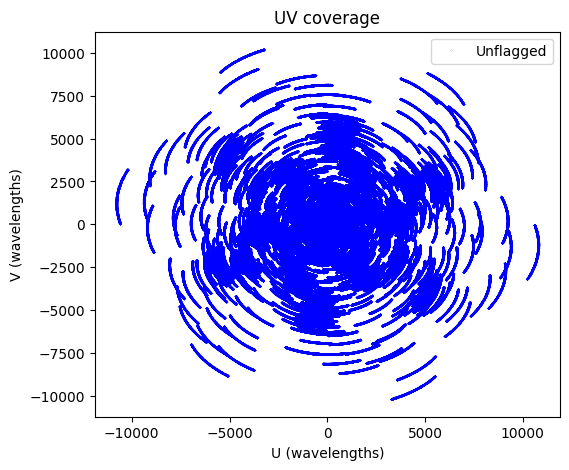

In [3]:
if vt.vis.size < 1e7:
    matplotlib.rcParams['figure.figsize'] = [6, 5]
    plot_uvcoverage([vt])


### Fill visibilities amplitude from (Fourier plane values) of image in FITS file. Cell size corresponds to the (advised) pixel angular size in radians. Uses Nifty gridder.

In [4]:
num_pix = helpers.readFits('../data/' + gt_name + '_full_gt.fits').shape[0]

vt, cell_size, im = visibilities_from_image(vt,'../data/' + gt_name + '_full_gt.fits',return_cellsize=True,return_image=True,scale_factor=1.8)

advise_wide_field: (max_wavelength) Maximum wavelength 5.996 (meters)
advise_wide_field: (min_wavelength) Minimum wavelength 5.996 (meters)
advise_wide_field: (maximum_baseline) Maximum baseline 10809.3 (wavelengths)
advise_wide_field: (maximum_w) Maximum w 2554.0 (wavelengths)
advise_wide_field: (diameter) Station/dish diameter 38.0 (meters)
advise_wide_field: (primary_beam_fov) Primary beam 0.158 (rad) 9.04 (deg) 3.25e+04 (asec)
advise_wide_field: (image_fov) Image field of view 0.473 (rad) 27.1 (deg) 9.76e+04 (asec)
advise_wide_field: (synthesized_beam) Synthesized beam 9.25e-05 (rad) 0.0053 (deg) 19.1 (asec)
advise_wide_field: (cellsize) Cellsize 2.31e-05 (rad) 0.00133 (deg) 4.77 (asec)
advice_wide_field: (npixels) Npixels per side = 20467
advice_wide_field: (npixels2) Npixels (power of 2) per side = 32768
advice_wide_field: (npixels23) Npixels (power of 2, 3) per side = 24576
advice_wide_field: (npixels_min) Npixels (power of 2, 3, 4, 5) per side = 20475

advice_wide_field: (w_sam

### Add artificial noise, this is currently based on the source but an option should be added for it to be based on the sensitivity (https://www.skao.int/en/science-users/ska-tools/493/ska-sensitivity-calculators)

In [5]:
percentage = 0.02

stdv_real = numpy.std(numpy.array(vt.vis.real).flatten())
stdv_imag = numpy.std(numpy.array(vt.vis.imag).flatten())

stdv_real *= percentage
stdv_imag *= percentage

noise_real = numpy.random.normal(loc=0, scale=stdv_real, size=vt.vis.shape)
noise_imag = numpy.random.normal(loc=0, scale=stdv_imag, size=vt.vis.shape) 

noise = numpy.vectorize(complex)(noise_real, noise_imag)
vt["vis"].data = vt.vis + noise

### Visualize dirty and psf and their Fourier transforms

create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -35.)>, starting frequency 50000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 10809.288317 wavelengths
create_image_from_visibility: Critical cellsize = 0.000046 radians, 0.002650 degrees
create_image_from_visibility: Cellsize = 4.16309e-05 radians, 0.00238527 degrees
create_image_from_visibility: image shape is (1, 1, 512, 512)
(1, 1, 512, 512)
Model image plate scale (arcsec) is 8.586982e+00


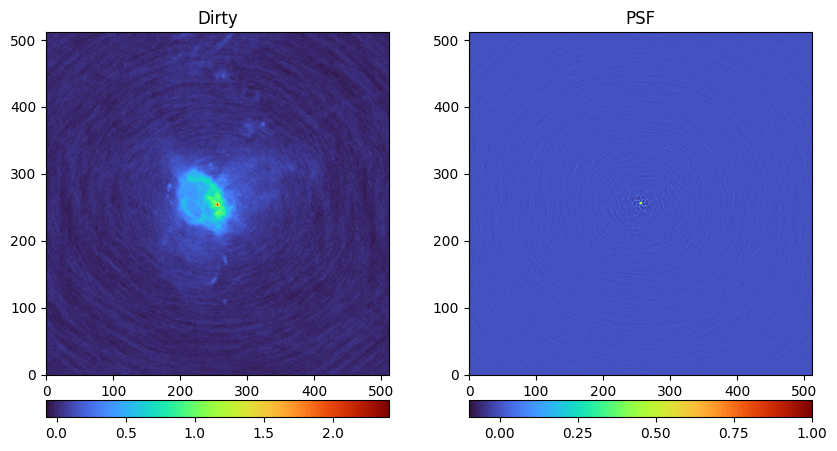

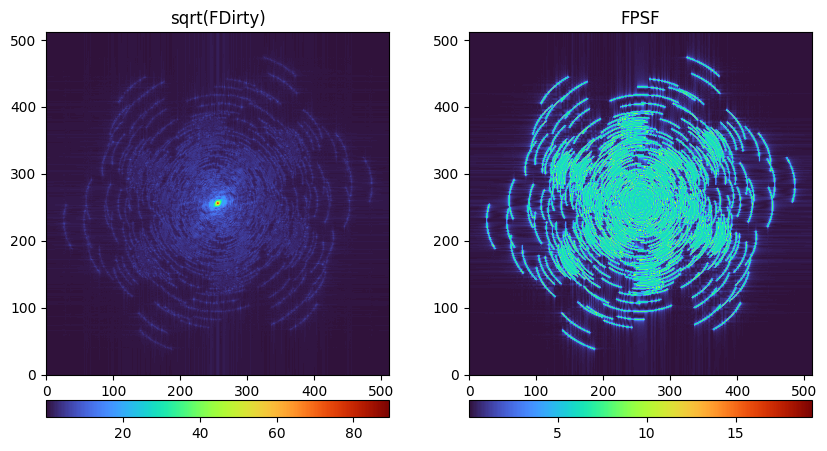

In [6]:
matplotlib.rcParams['figure.figsize'] = [10, 5]

dirty, psf = dirty_psf_from_visibilities(vt,cell_size,npix=num_pix,weighting="uniform", override_cellsize=False)
helpers.plotNImages([dirty.pixels.data[0,0,:,:], psf.pixels.data[0, 0,:,:]], ["Dirty", "PSF"], cmap=cmap)

fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(dirty.pixels.data[0,0,:,:]))))
fpsf = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(psf.pixels.data[0,0,:,:]))))
helpers.plotNImages([fdirty ** 0.5, fpsf], ["sqrt(FDirty)", "FPSF"], cmap="turbo")

### Plot visibility amplitudes as a function of uv radius

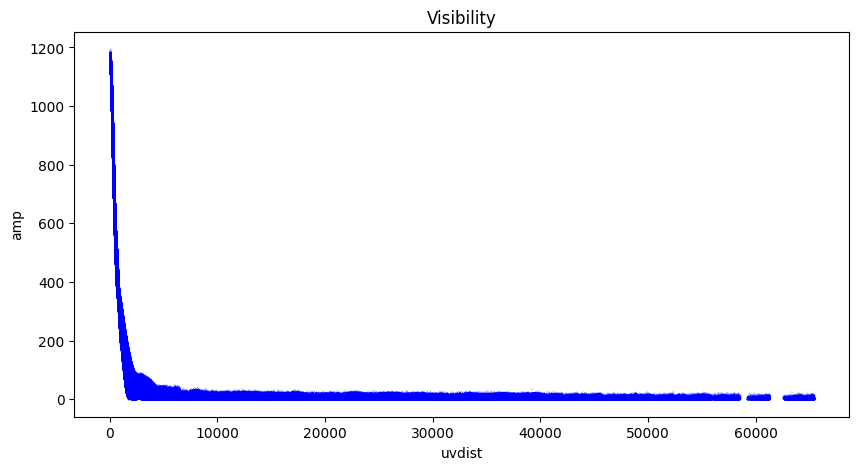

In [7]:
#vv = np.ones(vt.vis.shape)
#vt["vis"].data = vv
import math
plot_visibility([vt])
u = vt.visibility_acc.u.data
v = vt.visibility_acc.v.data

max_dist = 0

uv=vt.visibility_acc.uvw_lambda[...,0:2]
nrows,nbaselines, _ = vt.uvw.shape
uv = uv.reshape(nrows*nbaselines*len(frequencies),2)

max_dist = 0
c = numpy.zeros(nrows*nbaselines*len(frequencies))
for i, uval in enumerate(uv):
    c[i] = math.sqrt(uval[0] ** 2 + uval[1] ** 2)
    
nfreq = len(frequencies)

c = numpy.zeros((nrows, nbaselines, nfreq))
for i in range(nbaselines):
    c[:,i,:] = float(i) / nbaselines
c = numpy.imag(vt.vis.data)


### Export visibility data to measurement set file

In [8]:
from rascil.processing_components import export_visibility_to_ms

full_ms_name = '../data7/' + gt_name + '_' + config_name + '_serial.ms'
output_name = '../data7/' + gt_name + '_' + config_name

export_visibility_to_ms(full_ms_name,[vt])

## Split datasets

### Obtain separation thresholds in lambda units

In [17]:
ells = [3, 10, 35, 70]
delta = 1

### Load saved full dataset into casa and split it into two partitions

In [18]:
#I have to do things this way because for some reason importing the casatools library here crashes the notebook..

centers_str = ""
for ell in ells:
    centers_str += str(ell) + " "
    
split_exec = "python split_datasets.py --idataset_name " + full_ms_name + " --num_pix " + str(num_pix) + \
    " --pix_rad " + str(cell_size) + " --halfwidth " + str(delta) + " --centers " + centers_str + \
    "--odataset_name " + output_name

os.system(split_exec)

2025-01-16 14:56:08	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-01-16 14:56:23	INFO	SubMS::makeSelection()	2086602 out of 7879680 rows are going to be considered due to the selection criteria.
2025-01-16 14:56:32	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-01-16 14:56:46	INFO	SubMS::makeSelection()	1988280 out of 7879680 rows are going to be considered due to the selection criteria.
2025-01-16 14:56:54	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-01-16 14:57:07	INFO	SubMS::makeSelection()	1945233 out of 7879680 rows are going to be considered due to the selection criteria.
2025-01-16 14:57:15	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-01-16 14:57:26	INFO	SubMS::makeSelection()	1367074 out of 7879680 rows are going to be considered due to the selection criteria.
2025-01-16 14:57:32	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-01-16 14:57:43	INFO	SubMS::makeSelection()	1588205 out of 7879680 rows are going to be considered due to the 

0

### Load short and long baseline measurement sets, plot uv coverage

create_visibility_from_ms: {'type': 'Measurement Set', 'subType': 'UVFITS', 'readme': 'This is a MeasurementSet Table holding measurements from a Telescope\nThis is a measurement set Table holding astronomical observations\n'}
create_visibility_from_ms: Reading unique fields [0], unique data descriptions [0]
create_visibility_from_ms: Found 2086602 rows
create_visibility_from_ms: Found 1 channels
create_visibility_from_ms: Reading all 1 channels
create_visibility_from_ms: Observation from 2000-01-01 12:15:59.772 to 2000-01-01 14:13:59.772


/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:87: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  super().__init__(data_vars, coords=coords, attrs=attrs)


There is no flagged visibility. Skip plotting flagged.


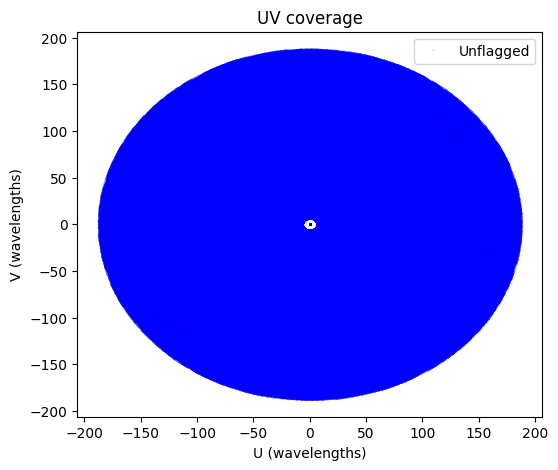

create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -35.)>, starting frequency 50000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 187.613944 wavelengths
create_image_from_visibility: Critical cellsize = 0.002665 radians, 0.152696 degrees
create_image_from_visibility: Cellsize = 4.16309e-05 radians, 0.00238527 degrees
create_image_from_visibility: image shape is (1, 1, 512, 512)
(1, 1, 512, 512)
Model image plate scale (arcsec) is 8.586982e+00
create_visibility_from_ms: {'type': 'Measurement Set', 'subType': 'UVFITS', 'readme': 'This is a MeasurementSet Table holding measurements from a Telescope\nThis is a measurement set Table holding astronomical observations\n'}
create_visibility_from_ms: Reading unique fields [0], unique data descriptions [0]
create_visibility_from_ms: Found 1988280 rows
create_visibility_from_ms: Found 1 cha

/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:87: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  super().__init__(data_vars, coords=coords, attrs=attrs)


There is no flagged visibility. Skip plotting flagged.


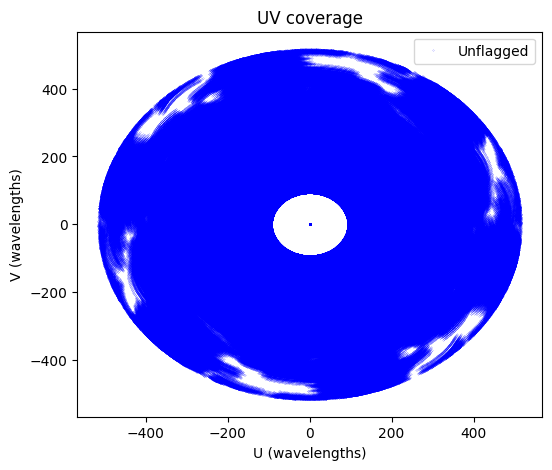

create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -35.)>, starting frequency 50000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 516.020029 wavelengths
create_image_from_visibility: Critical cellsize = 0.000969 radians, 0.055517 degrees
create_image_from_visibility: Cellsize = 4.16309e-05 radians, 0.00238527 degrees
create_image_from_visibility: image shape is (1, 1, 512, 512)
(1, 1, 512, 512)
Model image plate scale (arcsec) is 8.586982e+00
create_visibility_from_ms: {'type': 'Measurement Set', 'subType': 'UVFITS', 'readme': 'This is a MeasurementSet Table holding measurements from a Telescope\nThis is a measurement set Table holding astronomical observations\n'}
create_visibility_from_ms: Reading unique fields [0], unique data descriptions [0]
create_visibility_from_ms: Found 1945233 rows
create_visibility_from_ms: Found 1 cha

/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:87: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  super().__init__(data_vars, coords=coords, attrs=attrs)


There is no flagged visibility. Skip plotting flagged.


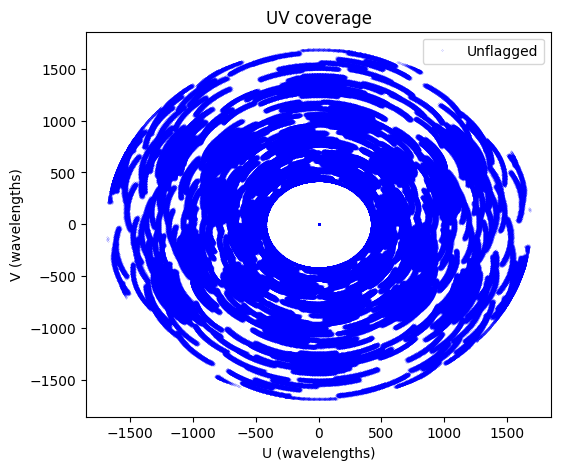

create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -35.)>, starting frequency 50000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 1688.337086 wavelengths
create_image_from_visibility: Critical cellsize = 0.000296 radians, 0.016968 degrees
create_image_from_visibility: Cellsize = 4.16309e-05 radians, 0.00238527 degrees
create_image_from_visibility: image shape is (1, 1, 512, 512)
(1, 1, 512, 512)
Model image plate scale (arcsec) is 8.586982e+00
create_visibility_from_ms: {'type': 'Measurement Set', 'subType': 'UVFITS', 'readme': 'This is a MeasurementSet Table holding measurements from a Telescope\nThis is a measurement set Table holding astronomical observations\n'}
create_visibility_from_ms: Reading unique fields [0], unique data descriptions [0]
create_visibility_from_ms: Found 1367074 rows
create_visibility_from_ms: Found 1 ch

/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:87: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  super().__init__(data_vars, coords=coords, attrs=attrs)


There is no flagged visibility. Skip plotting flagged.


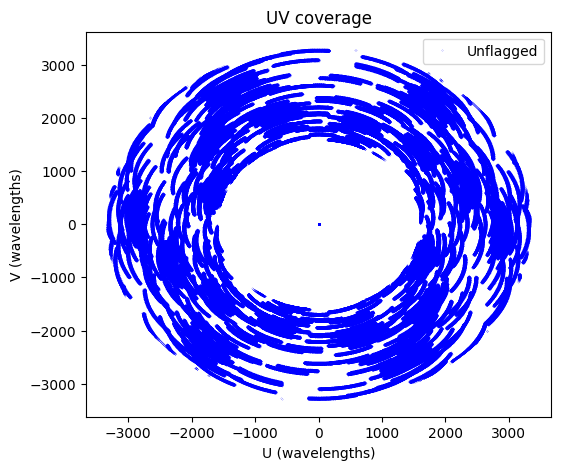

create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -35.)>, starting frequency 50000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 3330.928567 wavelengths
create_image_from_visibility: Critical cellsize = 0.000150 radians, 0.008601 degrees
create_image_from_visibility: Cellsize = 4.16309e-05 radians, 0.00238527 degrees
create_image_from_visibility: image shape is (1, 1, 512, 512)
(1, 1, 512, 512)
Model image plate scale (arcsec) is 8.586982e+00
create_visibility_from_ms: {'type': 'Measurement Set', 'subType': 'UVFITS', 'readme': 'This is a MeasurementSet Table holding measurements from a Telescope\nThis is a measurement set Table holding astronomical observations\n'}
create_visibility_from_ms: Reading unique fields [0], unique data descriptions [0]
create_visibility_from_ms: Found 1588205 rows
create_visibility_from_ms: Found 1 ch

/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:87: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  super().__init__(data_vars, coords=coords, attrs=attrs)


There is no flagged visibility. Skip plotting flagged.


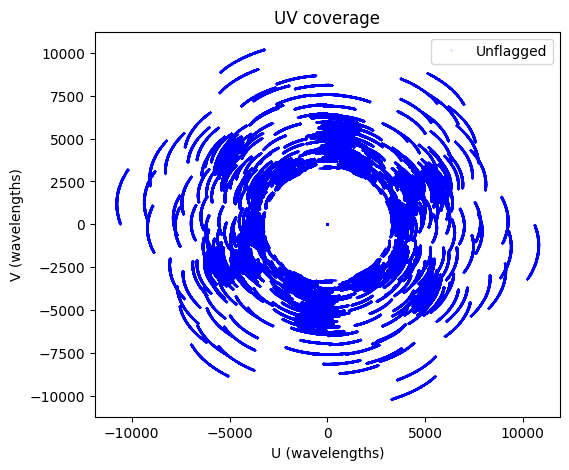

create_image_from_visibility: Parsing parameters to get definition of WCS
create_image_from_visibility: Defining single channel Image at <SkyCoord (ICRS): (ra, dec) in deg
    (56., -35.)>, starting frequency 50000000.0 Hz, and bandwidth 1000000.0 Hz
create_image_from_visibility: uvmax = 10809.288317 wavelengths
create_image_from_visibility: Critical cellsize = 0.000046 radians, 0.002650 degrees
create_image_from_visibility: Cellsize = 4.16309e-05 radians, 0.00238527 degrees
create_image_from_visibility: image shape is (1, 1, 512, 512)
(1, 1, 512, 512)
Model image plate scale (arcsec) is 8.586982e+00


In [19]:
matplotlib.rcParams['figure.figsize'] = [6, 5]

from rascil.processing_components import create_visibility_from_ms

psfs = []
dirties = []
fdirties = []

for ell in ells:
    curr_ms_file = output_name + str(ell) + ".ms"
    [vis] = create_visibility_from_ms(curr_ms_file)
    
    if vis.vis.size < 5e7:
        plot_uvcoverage([vis])
    
    curr_dirty, curr_psf = dirty_psf_from_visibilities(vis,cell_size,npix=num_pix,weighting="uniform")
    fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(curr_dirty.pixels.data[0,0,:,:]))))
    
    psfs.append(curr_psf)
    dirties.append(curr_dirty)
    fdirties.append(fdirty)
    
curr_ms_file = output_name + str(ells[-1]) + "plus.ms"
[vis] = create_visibility_from_ms(curr_ms_file)

if vis.vis.size < 5e7:
    plot_uvcoverage([vis])

curr_dirty, curr_psf = dirty_psf_from_visibilities(vis,cell_size,npix=num_pix,weighting="uniform")
fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(curr_dirty.pixels.data[0,0,:,:]))))

psfs.append(curr_psf)
dirties.append(curr_dirty)
fdirties.append(fdirty)

### Partitions and full dataset compared in a grid

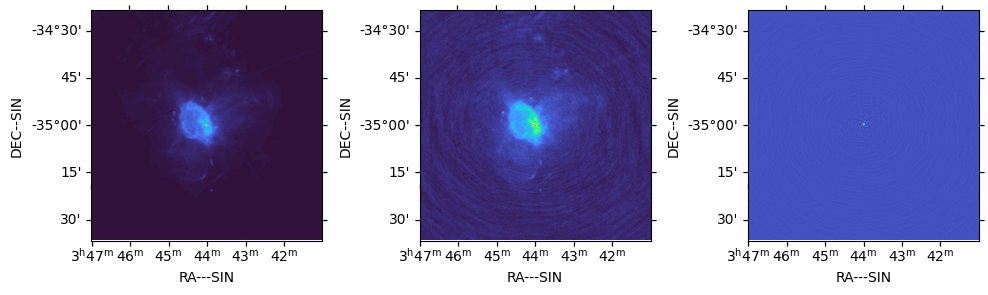

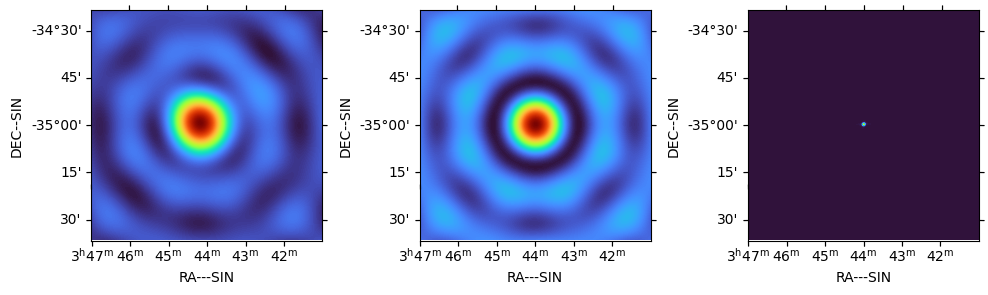

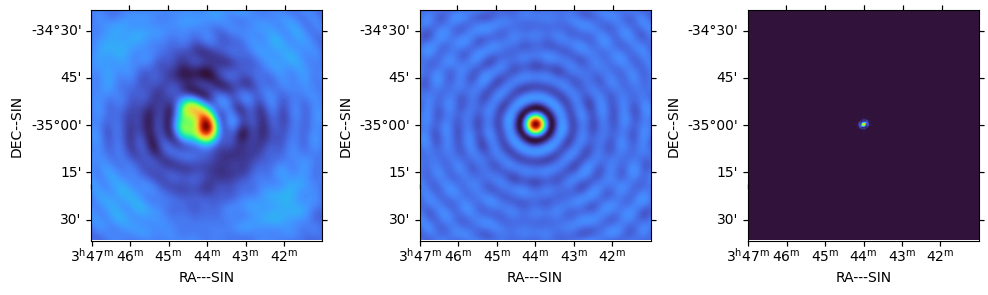

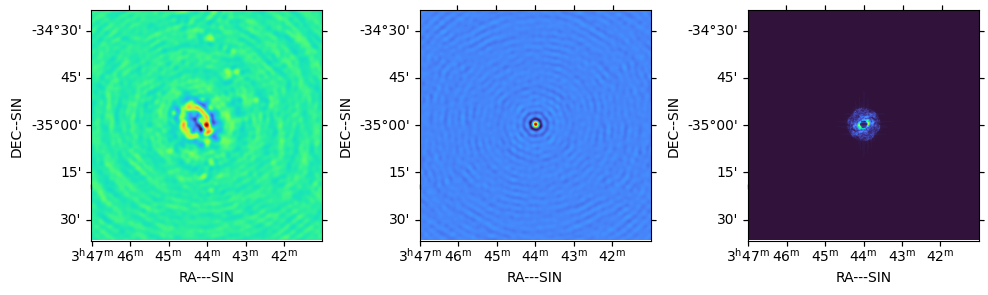

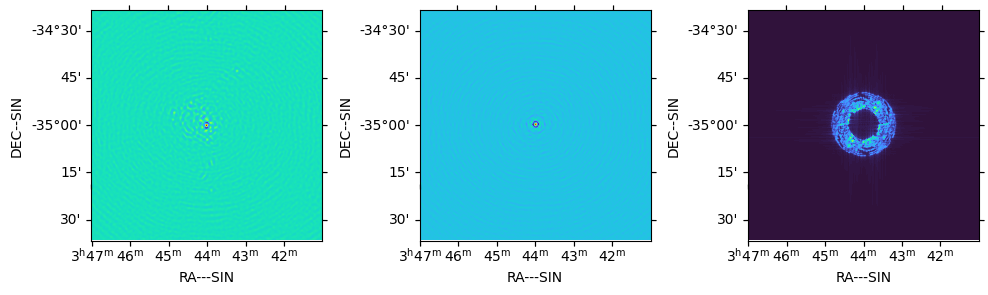

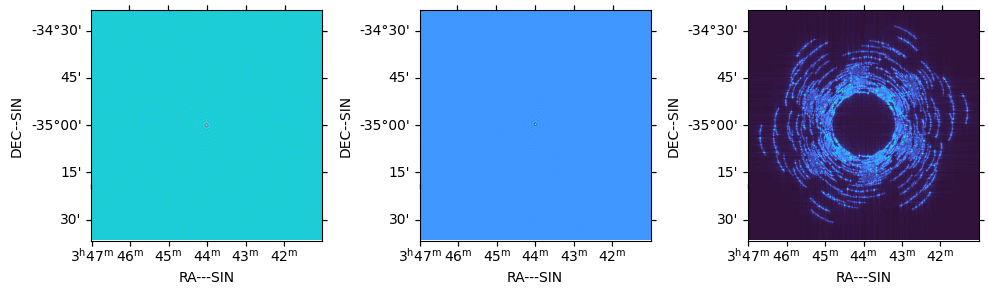

In [21]:
num_datasets = len(ells) + 1

fig = plt.figure(figsize=(12,3))
ax=fig.add_subplot(1,3,1,projection=im.image_acc.wcs.sub([1, 2]))
ax.imshow(im.pixels.data[0,0,:,:],origin='lower',cmap=cmap)
ax.set_xlabel(im.image_acc.wcs.wcs.ctype[0])
ax.set_ylabel(im.image_acc.wcs.wcs.ctype[1])

ax=fig.add_subplot(1,3,2,projection=dirty.image_acc.wcs.sub([1, 2]))
ax.imshow(dirty.pixels.data[0,0,:,:],origin='lower',cmap=cmap)
ax.set_xlabel(dirty.image_acc.wcs.wcs.ctype[0])
ax.set_ylabel(dirty.image_acc.wcs.wcs.ctype[1])

ax=fig.add_subplot(1,3,3,projection=psf.image_acc.wcs.sub([1, 2]))
ax.imshow(psf.pixels.data[0,0,:,:],origin='lower',cmap=cmap)
ax.set_xlabel(psf.image_acc.wcs.wcs.ctype[0])
ax.set_ylabel(psf.image_acc.wcs.wcs.ctype[1])

#display all partitions
for i, curr_dirty in enumerate(dirties):
    fig = plt.figure(figsize=(12,3))
    ax=fig.add_subplot(1,3,1,projection=dirties[i].image_acc.wcs.sub([1, 2]))
    ax.imshow(dirties[i].pixels.data[0,0,:,:],origin='lower',cmap=cmap)
    ax.set_xlabel(dirties[i].image_acc.wcs.wcs.ctype[0])
    ax.set_ylabel(dirties[i].image_acc.wcs.wcs.ctype[1])

    ax=fig.add_subplot(1,3,2,projection=psfs[i].image_acc.wcs.sub([1, 2]))
    ax.imshow(psfs[i].pixels.data[0,0,:,:],origin='lower',cmap=cmap)
    ax.set_xlabel(psfs[i].image_acc.wcs.wcs.ctype[0])
    ax.set_ylabel(psfs[i].image_acc.wcs.wcs.ctype[1])

    ax=fig.add_subplot(1,3,3,projection=dirties[i].image_acc.wcs.sub([1, 2]))
    ax.imshow(fdirties[i],origin='lower',cmap=cmap)
    ax.set_xlabel(dirties[i].image_acc.wcs.wcs.ctype[0])
    ax.set_ylabel(dirties[i].image_acc.wcs.wcs.ctype[1])


### Export dirty, psf to fits

In [22]:
# Export dirty, psf
dirty.image_acc.export_to_fits('../data7/' + gt_name + '_dirty.fits')
psf.image_acc.export_to_fits('../data7/'  + gt_name + '_psf.fits')

### Comparison of PSF Shapes

(-0.5, 1.1)

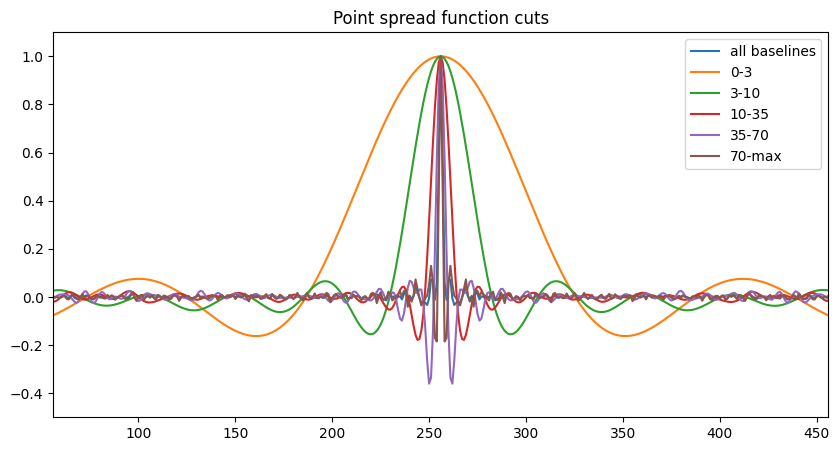

In [25]:
matplotlib.rcParams['figure.figsize'] = [10, 5]

size = 200

plt.plot(psf['pixels'].data[0,0,256,:],label='all baselines')
for i, curr_psf in enumerate(psfs):
    curr_range_low = 0 if i == 0 else ells[i - 1]
    curr_range_high = ells[i] if i < len(ells) else "max"
    range_label = str(curr_range_low) + "-" + str(curr_range_high)
    plt.plot(curr_psf['pixels'].data[0,0,256,:],label=range_label)
    
plt.legend()
plt.title('Point spread function cuts')
plt.xlim((256 - size, 256 + size)); plt.ylim((-0.5,1.1))